# Logistic Regression — Diabetes 30-Day Readmission

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    f1_score,
    precision_recall_curve,
    PrecisionRecallDisplay,
)

In [2]:
X_train_full = pd.read_csv('../Data/X_train.csv')
X_test_full  = pd.read_csv('../Data/X_test.csv')
y_train      = pd.read_csv('../Data/y_train.csv').squeeze()
y_test       = pd.read_csv('../Data/y_test.csv').squeeze()

# Top features selected in feature_importance.ipynb
top_features = pd.read_csv('../Data/top_features.csv', header=None).squeeze().tolist()

X_train_top = X_train_full[top_features]
X_test_top  = X_test_full[top_features]

print(f'All features:  {X_train_full.shape[1]}')
print(f'Top features:  {len(top_features)}')
print(f'Train samples: {X_train_full.shape[0]}  |  Test samples: {X_test_full.shape[0]}')
print(f'Positive rate: {y_train.mean():.3f}')

All features:  89
Top features:  17
Train samples: 55989  |  Test samples: 13998
Positive rate: 0.090


## 1.5 Interaction Features

Logistic regression is linear — it cannot discover that two features *together* predict readmission better than either alone. We explicitly create clinically motivated cross-products to capture these joint effects before fitting the model.

In [3]:
interactions = {
    'inpatient_x_medications': ('number_inpatient', 'num_medications'),
    'inpatient_x_time':        ('number_inpatient', 'time_in_hospital'),
    'age_x_diagnoses':         ('age',              'number_diagnoses'),
    'age_x_inpatient':         ('age',              'number_inpatient'),
    'insulin_x_inpatient':     ('insulin',          'number_inpatient'),
}

for name, (a, b) in interactions.items():
    X_train_top[name] = X_train_top[a] * X_train_top[b]
    X_test_top[name]  = X_test_top[a]  * X_test_top[b]

print(f'Features after adding interactions: {X_train_top.shape[1]}')
print('Interaction columns added:', list(interactions.keys()))

Features after adding interactions: 22
Interaction columns added: ['inpatient_x_medications', 'inpatient_x_time', 'age_x_diagnoses', 'age_x_inpatient', 'insulin_x_inpatient']


/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_7854/4072281387.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_top[name] = X_train_top[a] * X_train_top[b]
/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_7854/4072281387.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_top[name]  = X_test_top[a]  * X_test_top[b]
/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_7854/4072281387.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

## 2. Baseline Model

In [4]:
# All features, no class weighting, default 0.5 threshold
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_full, y_train)

base_pred      = baseline.predict(X_test_full)
base_pred_prob = baseline.predict_proba(X_test_full)[:, 1]

print('Baseline Classification Report:')
print(classification_report(y_test, base_pred, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, base_pred_prob):.4f}')

Baseline Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.91      1.00      0.95     12741
Readmitted <30       0.31      0.00      0.01      1257

      accuracy                           0.91     13998
     macro avg       0.61      0.50      0.48     13998
  weighted avg       0.86      0.91      0.87     13998

ROC-AUC: 0.6480


## 3. Tuned Model

In [5]:
# Top features only, class_weight='balanced' to handle class imbalance
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_top, y_train)

y_pred = model.predict(X_test_top)
y_pred_prob = model.predict_proba(X_test_top)[:, 1]

print('Tuned Model Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}')

Tuned Model Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.71      0.80     12741
Readmitted <30       0.14      0.50      0.22      1257

      accuracy                           0.69     13998
     macro avg       0.54      0.60      0.51     13998
  weighted avg       0.86      0.69      0.75     13998

ROC-AUC: 0.6448


In [6]:
# The default 0.5 threshold is not optimal for imbalanced data
# Sweep thresholds and pick the one that maximizes F1 for the minority class
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y_test, (y_pred_prob >= t).astype(int), pos_label=1, zero_division=0)
              for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1     = max(f1_scores)

In [7]:
# Re-evaluate tuned model at optimal threshold
y_pred_best = (y_pred_prob >= best_thresh).astype(int)

print(f'Tuned Model at threshold = {best_thresh:.2f}:')
print(classification_report(y_test, y_pred_best, target_names=['Not Readmitted', 'Readmitted <30']))

Tuned Model at threshold = 0.56:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.83      0.88     12741
Readmitted <30       0.17      0.37      0.24      1257

      accuracy                           0.79     13998
     macro avg       0.55      0.60      0.56     13998
  weighted avg       0.86      0.79      0.82     13998



Looking at f1 score raw it looks very low but when I do a macro average where I calculate the metrics for each class seperately, then take a simple unweighted average I can get a more honest picture of model performance across both classes. I did this since their is major class imbalance in this dataset.

## 4. SMOTE Model

**What is SMOTE?**

The tuned model above still struggles because even with `class_weight='balanced'`, the model has only seen 5,028 real readmission examples during training. SMOTE (Synthetic Minority Over-sampling Technique) fixes this by *creating new training examples* for the minority class instead of just reweighting the loss.

How it works in plain English:
1. Pick a real "Readmitted <30" sample.
2. Find its k nearest neighbors (also minority samples) in feature space.
3. Draw a new synthetic point somewhere on the line connecting them.
4. Repeat until both classes are the same size.

The test set is never touched — SMOTE only changes what the model learns from, not how we evaluate it. Because the training set is now balanced, `class_weight='balanced'` is no longer needed.

In [8]:
# ── Step 1: Apply SMOTE to the training set only ─────────────────────────────
# SMOTE synthesises new minority-class points by picking a real minority sample,
# finding one of its nearest neighbors, and placing a new point somewhere on the
# line between them. Repeat until the two classes are equal in size.
# The test set is NEVER touched — we still evaluate on the real distribution.

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_top, y_train)

print('Class counts BEFORE SMOTE (training set):')
before = pd.Series(y_train).value_counts().rename({0: 'Not Readmitted', 1: 'Readmitted <30'})
print(before.to_string())

print('\nClass counts AFTER SMOTE (training set):')
after = pd.Series(y_train_smote).value_counts().rename({0: 'Not Readmitted', 1: 'Readmitted <30'})
print(after.to_string())
print(f'\nSynthetic minority samples created: {after["Readmitted <30"] - before["Readmitted <30"]:,}')

# ── Step 2: Train — no class_weight needed, SMOTE already balanced the data ──
smote_model = LogisticRegression(max_iter=1000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)

smote_pred_prob = smote_model.predict_proba(X_test_top)[:, 1]

# Same threshold sweep used for the tuned model
smote_f1_scores   = [f1_score(y_test, (smote_pred_prob >= t).astype(int),
                               pos_label=1, zero_division=0) for t in thresholds]
smote_best_thresh = thresholds[np.argmax(smote_f1_scores)]
smote_pred_best   = (smote_pred_prob >= smote_best_thresh).astype(int)

print(f'\nSMOTE Model at threshold = {smote_best_thresh:.2f}:')
print(classification_report(y_test, smote_pred_best, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, smote_pred_prob):.4f}')

Class counts BEFORE SMOTE (training set):
readmitted
Not Readmitted    50961
Readmitted <30     5028

Class counts AFTER SMOTE (training set):
readmitted
Not Readmitted    50961
Readmitted <30    50961

Synthetic minority samples created: 45,933



SMOTE Model at threshold = 0.55:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.81      0.87     12741
Readmitted <30       0.16      0.36      0.22      1257

      accuracy                           0.77     13998
     macro avg       0.54      0.59      0.54     13998
  weighted avg       0.86      0.77      0.81     13998

ROC-AUC: 0.6128


## 5. Model Comparison

In [9]:
from sklearn.metrics import precision_score, recall_score

results = {
    'Model':                ['Baseline', 'Tuned', 'SMOTE'],
    'Features':             [X_train_full.shape[1], len(top_features), len(top_features)],
    'Imbalance handling':   ['None', 'class_weight=balanced', 'SMOTE oversampling'],
    'Threshold':            [0.50, round(best_thresh, 2), round(smote_best_thresh, 2)],
    'Precision (minority)': [
        round(precision_score(y_test, base_pred,       pos_label=1, zero_division=0), 3),
        round(precision_score(y_test, y_pred_best,     pos_label=1, zero_division=0), 3),
        round(precision_score(y_test, smote_pred_best, pos_label=1, zero_division=0), 3),
    ],
    'Recall (minority)': [
        round(recall_score(y_test, base_pred),       3),
        round(recall_score(y_test, y_pred_best),     3),
        round(recall_score(y_test, smote_pred_best), 3),
    ],
    'F1 (minority)': [
        round(f1_score(y_test, base_pred,       pos_label=1, zero_division=0), 3),
        round(f1_score(y_test, y_pred_best,     pos_label=1, zero_division=0), 3),
        round(f1_score(y_test, smote_pred_best, pos_label=1, zero_division=0), 3),
    ],
    'Macro F1': [
        round(f1_score(y_test, base_pred,       average='macro', zero_division=0), 3),
        round(f1_score(y_test, y_pred_best,     average='macro', zero_division=0), 3),
        round(f1_score(y_test, smote_pred_best, average='macro', zero_division=0), 3),
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, base_pred_prob),  4),
        round(roc_auc_score(y_test, y_pred_prob),     4),
        round(roc_auc_score(y_test, smote_pred_prob), 4),
    ],
}

pd.DataFrame(results)

,Model,Features,Imbalance handling,Threshold,Precision (minority),Recall (minority),F1 (minority),Macro F1,ROC-AUC
0,Baseline,89,None,0.50,0.308,0.003,0.006,0.480,0.6480
1,Tuned,17,class_weight=balanced,0.56,0.174,0.368,0.236,0.556,0.6448
2,SMOTE,17,SMOTE oversampling,0.55,0.159,0.363,0.221,0.543,0.6128


## 6. Confusion Matrices

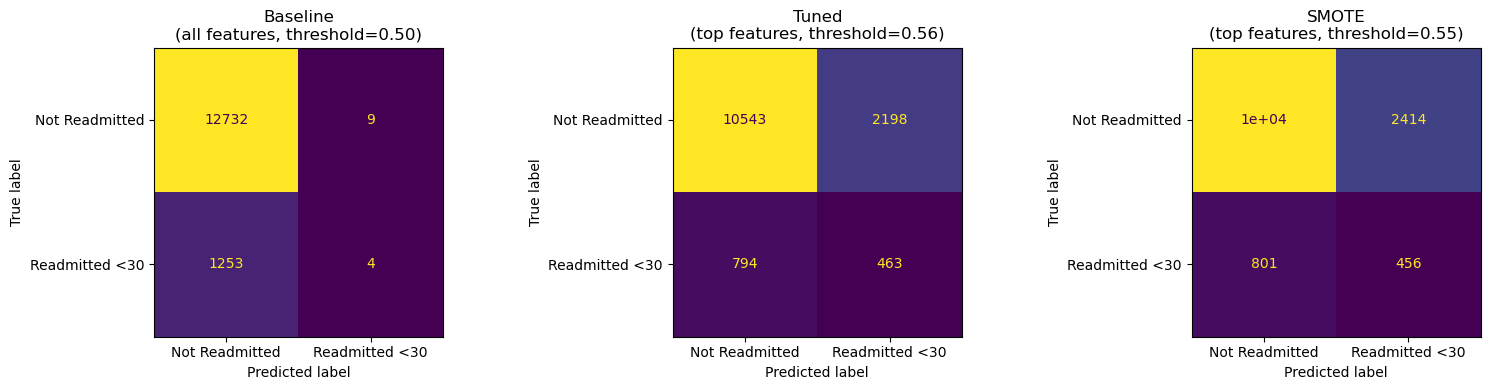

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, base_pred),
    display_labels=['Not Readmitted', 'Readmitted <30']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Baseline\n(all features, threshold=0.50)')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_best),
    display_labels=['Not Readmitted', 'Readmitted <30']
).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Tuned\n(top features, threshold={best_thresh:.2f})')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, smote_pred_best),
    display_labels=['Not Readmitted', 'Readmitted <30']
).plot(ax=axes[2], colorbar=False)
axes[2].set_title(f'SMOTE\n(top features, threshold={smote_best_thresh:.2f})')

plt.tight_layout()
plt.savefig('../Results/LR_Results/confusion_matrix_lr.png', dpi=150)
plt.show()

## 7. ROC Curve & Precision-Recall Curve

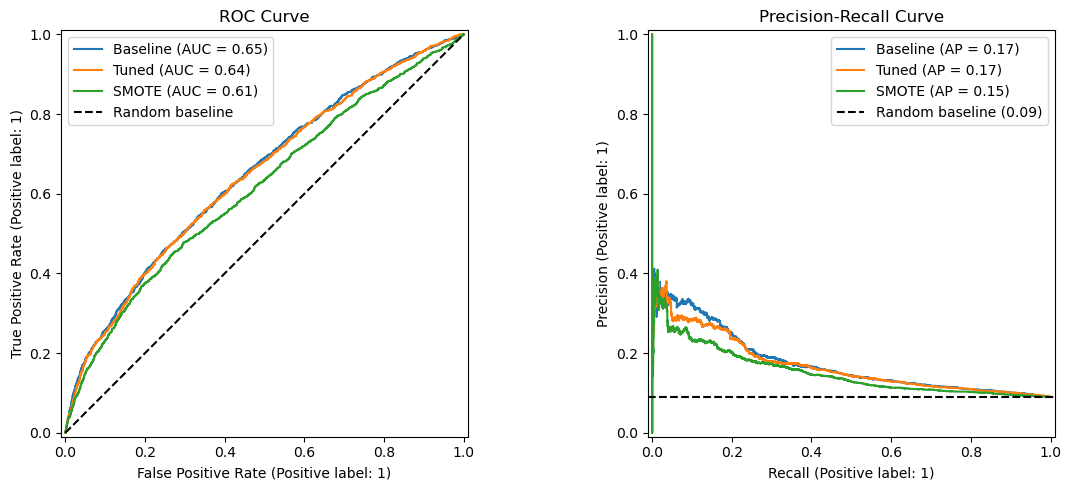

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, base_pred_prob,  ax=axes[0], name='Baseline')
RocCurveDisplay.from_predictions(y_test, y_pred_prob,     ax=axes[0], name='Tuned')
RocCurveDisplay.from_predictions(y_test, smote_pred_prob, ax=axes[0], name='SMOTE')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random baseline')
axes[0].set_title('ROC Curve')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, base_pred_prob,  ax=axes[1], name='Baseline')
PrecisionRecallDisplay.from_predictions(y_test, y_pred_prob,     ax=axes[1], name='Tuned')
PrecisionRecallDisplay.from_predictions(y_test, smote_pred_prob, ax=axes[1], name='SMOTE')
baseline_rate = y_test.mean()
axes[1].axhline(baseline_rate, color='k', linestyle='--', label=f'Random baseline ({baseline_rate:.2f})')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('../Results/LR_Results/roc_pr_curves_lr.png', dpi=150)
plt.show()

## 8. Tuned Model Coefficients

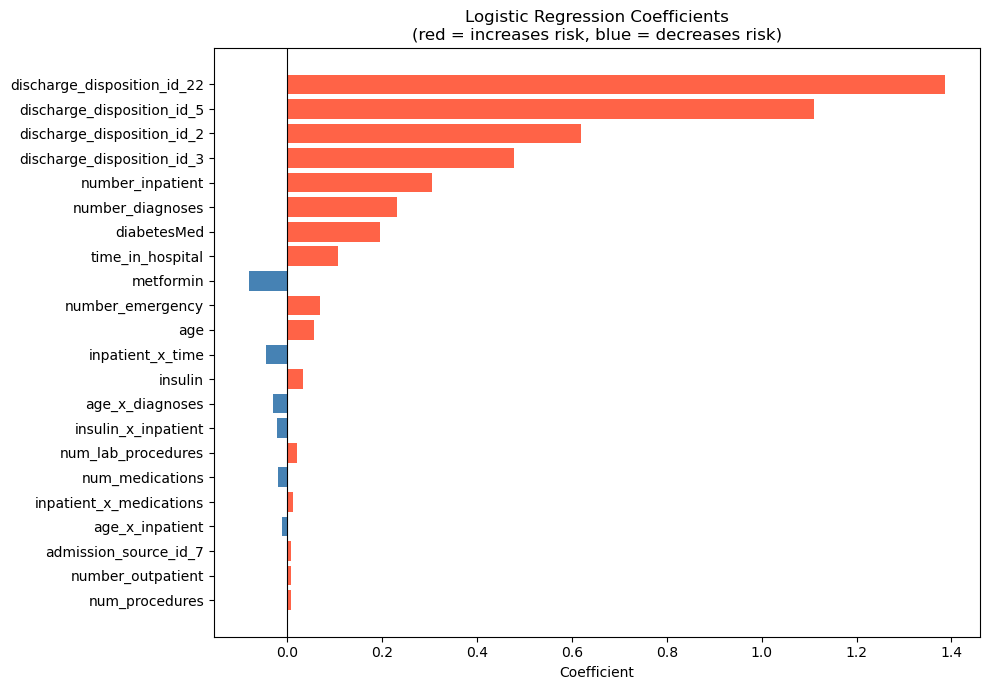

In [12]:
# Positive coefficient = increases readmission risk
# Negative coefficient = decreases readmission risk
feature_names = X_train_top.columns.tolist()

coef_df = (
    pd.DataFrame({'feature': feature_names, 'coefficient': model.coef_[0]})
    .reindex(pd.Series(model.coef_[0]).abs().sort_values(ascending=False).index)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('Logistic Regression Coefficients\n(red = increases risk, blue = decreases risk)')
plt.tight_layout()
plt.savefig('../Results/LR_Results/lr_coefficients.png', dpi=150)
plt.show()